### chatbot 

In [127]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [128]:
class state(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]#add mssges inside list with help of add_mssges
       

In [129]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

In [130]:
from langchain_groq import ChatGroq
model = ChatGroq(model="openai/gpt-oss-120b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002A2E8271390>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002A2E8270F30>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [131]:
# NODE( chatbot) functionality

def chatbot(state:state):
    return {"messages":[model.invoke(state["messages"])]}

In [132]:
graph_builder= StateGraph(state)

#add node
graph_builder.add_node("llmchatbot",chatbot)
#create node named llmchatbot and execute function chatbot for the node

#add edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

#compile the graph
graph = graph_builder.compile()

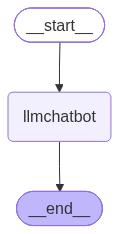

In [133]:
#visualize the graph 
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [134]:
response=graph.invoke({"messages":"Hi"})
response["messages"][-1].content

'Hello! How can I help you today?'

In [135]:
for event in graph.stream({"messages":"Hi How are you feeling?"}):
    for value in event.values():
        print(value["messages"][-1].content)

#  Graph starts
#      ↓
# Node 1 → event 1
#      ↓
# Node 2 → event 2
#      ↓
# Node 3 → event 3
#      ↓
# END

# So stream() ka use tab karte hain jab graph ke execution ko step-by-step dekhna/consume karna ho, instead of waiting for the complete graph.       

Hello! I'm just a virtual assistant, so I don't have feelings, but I'm ready and eager to help you with whatever you need. How can I assist you today?


# Chatbot with tools

In [136]:
from langchain_tavily import TavilySearch
tool = TavilySearch(max_result=1)#max search result
tool.invoke("is trump dead now?")

{'query': 'is trump dead now?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.aljazeera.com/news/2025/9/3/how-false-rumours-of-trumps-untimely-death-spread-on-social-media',
   'title': 'How false rumours of Trump’s untimely ‘death’ spread on social media | Donald Trump News | Al Jazeera',
   'content': 'By Maria Ramirez Uribe and Loreben Tuquero | Politifact\n\nPublished On 3 Sep 20253 Sep 2025\n\nSome people spent Labor Day weekend in the United States soaking up the last of the summer’s rays. Others took to social media to speculate that President Donald Trump was at death’s door, or worse.\n\nOn X, the hashtags #trumpisdead and #whereistrump trended. Millions of people made or watched videos on TikTok speculating that Trump had died or suffered a stroke or another serious medical emergency. [...] Even though Vance said multiple times that Trump is in good health, social media users jumped on his comments about being ready to assume 

In [137]:
#custom function(tool)
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [138]:
tools=[tool,multiply]

In [139]:
llm_with_tool=model.bind_tools(tools)

In [140]:

llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002A2E8271390>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002A2E8270F30>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, a

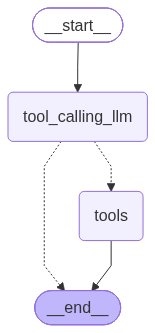

In [141]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}#jo binding kri h usko invoke krenge

## Graph
builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [142]:
res = graph.invoke({"messages":"what is recent india news in tech"})
res['messages'][-1].content

'{"query": "India technology news recent 2024 August", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bignewsnetwork.com/news/279218415/third-national-sustainable-agriculture-summit-awards-2026-to-convene-in-new-delhi-on-august-7-themed-krishi-samriddhi-2047", "title": "Third National Sustainable Agriculture Summit & Awards 2026 to Convene in New Delhi on August 7, Themed \'Krishi Samriddhi 2047\' - Big News Network.com", "score": 1.0, "published_date": "Sat, 01 Aug 2026 06:30:00 GMT", "content": "# Big News Network.com. # Third National Sustainable Agriculture Summit & Awards 2026 to Convene in New Delhi on August 7, Themed \'Krishi Samriddhi 2047\'. New Delhi [India], August 1: Sustainability Matters and IndiAgri, supported by the Alliance for Change, Transformation & Innovation (ACTION), will convene the 3rd National Sustainable Agriculture Summit & Awards 2026 on August 7 at the India International Centre, New Delhi. Themed \'Krishi Samr

In [143]:
for m in res['messages']:
    m.pretty_print()

================================ Human Message =================================

what is recent india news in tech
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_572499e9-1500-4d80-bb79-402c7b9497a4)
 Call ID: fc_572499e9-1500-4d80-bb79-402c7b9497a4
  Args:
    query: India technology news recent 2024 August
    search_depth: fast
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "India technology news recent 2024 August", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bignewsnetwork.com/news/279218415/third-national-sustainable-agriculture-summit-awards-2026-to-convene-in-new-delhi-on-august-7-themed-krishi-samriddhi-2047", "title": "Third National Sustainable Agriculture Summit & Awards 2026 to Convene in New Delhi on August 7, Themed 'Krishi Samriddhi 2047' - Big News Networ

In [144]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================

5 multiplied by 2 equals **10**.


In [145]:

response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
#tavily tool ka use krne ke baad end ho gya due to this dusre qn ka answer nhi aaya
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_11c0e7b6-ac37-49e5-980d-6e0545ab061d)
 Call ID: fc_11c0e7b6-ac37-49e5-980d-6e0545ab061d
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://carcc.org/2026/08/27/all-things-ai-september-2026", "title": "All Things AI – September 2026", "content": "NSF AI Datasets Program (NSF 26-512) — Full proposals due November 4. NSF has committed up to $100 million to making existing scientific datasets AI-ready — funding no new data collection, but investing in curation, harmonizati

# ReAct Agent Architecture

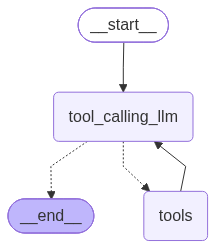

In [146]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}#jo binding kri h usko invoke krenge

## Graph
builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [147]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_66ec9dd4-50ce-4a42-967e-dfe18e6b1636)
 Call ID: fc_66ec9dd4-50ce-4a42-967e-dfe18e6b1636
  Args:
    query: latest AI news August 2026
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marketingprofs.com/opinions/2026/55727/ai-update-august-28-2026-ai-news-and-views-from-the-past-week", "title": "AI Update, August 28, 2026: AI News and Views From the ...", "content": "Startup unveils non-Transformer AI designed to model the physical world. Accelerated Understanding has unveiled an AI system built to model physical p

# adding memory in agentic graph

In [148]:
res = graph.invoke({"messages":"hello my name is vishu"})
for m in res['messages']:
    m.pretty_print()

================================ Human Message =================================

hello my name is vishu
================================== Ai Message ==================================

Hello, Vishu! Nice to meet you. How can I assist you today?


In [149]:
res = graph.invoke({"messages":"what is my name?"})
for m in res['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

I’m sorry, but I don’t have any information about your name. If you’d like to share it, feel free to let me know!


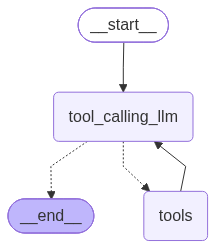

In [ ]:

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

#stores the data(memory) of every node
memory = MemorySaver()

## Node definition
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [152]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is vishu"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is vishu', additional_kwargs={}, response_metadata={}, id='46ea5453-2b2b-4f35-8758-89614c429e29'),
  AIMessage(content='Hello Vishu! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi my name is vishu". Probably a greeting. We can respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 348, 'total_tokens': 394, 'completion_time': 0.095340207, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.016349293, 'prompt_tokens_details': None, 'queue_time': 0.314085664, 'total_time': 0.1116895}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_3166198c1d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a04bef-0316-7632-a9d2-8be4bdca6884-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 348, 'output_tokens': 46, 'total_tokens': 394, 

In [153]:

response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Vishu.


# streaming

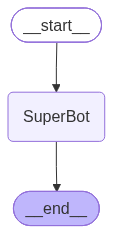

In [159]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:state):
    return {"messages":[model.invoke(state['messages'])]}


graph=StateGraph(state)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))    

In [160]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is vishu And I like cricket"},config)


{'messages': [HumanMessage(content='Hi,My name is vishu And I like cricket', additional_kwargs={}, response_metadata={}, id='c4e7f6f5-3890-4890-9756-a1698c243577'),
  AIMessage(content="Hello Vishu! 👋 Nice to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player? Are you more into watching matches, playing yourself, or maybe both? I'd love to hear what you enjoy most about the game!", additional_kwargs={'reasoning_content': 'We need to respond. The user says: "Hi, My name is vishu And I like cricket". We can respond friendly, ask about cricket preferences, etc. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 82, 'total_tokens': 185, 'completion_time': 0.213300922, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.003315254, 'prompt_tokens_details': None, 'queue_time': 0.324153675, 'total_time': 0.216616176}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9d1f936695', 'serv

# Streaming

## Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [161]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Krish! 👋 Great to meet you.  \n\nCricket’s a fantastic game—do you have a favorite team, player, or format (Test, ODI, T20)? Are you more of a fan watching the matches, or do you enjoy playing it yourself? Let me know what you love most about cricket!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". Likely they want a response. We should greet them, ask about cricket preferences. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 158, 'total_tokens': 270, 'completion_time': 0.238165222, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.00664514, 'prompt_tokens_details': None, 'queue_time': 0.158859989, 'total_time': 0.244810362}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6dedd2be22', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a04c0

In [162]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is vishu And I like cricket', additional_kwargs={}, response_metadata={}, id='c4e7f6f5-3890-4890-9756-a1698c243577'), AIMessage(content="Hello Vishu! 👋 Nice to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player? Are you more into watching matches, playing yourself, or maybe both? I'd love to hear what you enjoy most about the game!", additional_kwargs={'reasoning_content': 'We need to respond. The user says: "Hi, My name is vishu And I like cricket". We can respond friendly, ask about cricket preferences, etc. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 82, 'total_tokens': 185, 'completion_time': 0.213300922, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.003315254, 'prompt_tokens_details': None, 'queue_time': 0.324153675, 'total_time': 0.216616176}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9d1f936695', 'servic

In [163]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content='Hi,My name is vishu And I like cricket', additional_kwargs={}, response_metadata={}, id='c4e7f6f5-3890-4890-9756-a1698c243577'), AIMessage(content="Hello Vishu! 👋 Nice to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player? Are you more into watching matches, playing yourself, or maybe both? I'd love to hear what you enjoy most about the game!", additional_kwargs={'reasoning_content': 'We need to respond. The user says: "Hi, My name is vishu And I like cricket". We can respond friendly, ask about cricket preferences, etc. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 82, 'total_tokens': 185, 'completion_time': 0.213300922, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.003315254, 'prompt_tokens_details': None, 'queue_time': 0.324153675, 'total_time': 0.216616176}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9d1f936695', 'servic

In [164]:
#ASTREAM
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a04c04-1615-7db2-8bf6-a21464a07728', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='58b8e8f4-c43c-4bb9-9b81-d9374e5b493c')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a04c04-161c-73b3-81a2-3ce399806391', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:3d7b99e7-c9a2-f423-5a7f-5eadbf0e397c'}, 'parent_ids': ['01a04c04-1615-7db2-8bf6-a21464a07728']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':